Imports & Relative Path Setup

In [63]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import json

# --- CONFIGURATION ---
# Raw Download Folder (Input)
SOURCE_ROOT = Path("Kvasir-SEG") 
VALID_EXTS = {'.jpg', '.jpeg', '.png'}

# Cleaned Dataset Folder (Output)
SPLIT_CSV = SOURCE_ROOT / "splits.csv" 

# Split Ratios
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
SEED = 42

print(f"🔧 Project Root: {Path.cwd()}")
print(f"📄 Split file:   {SPLIT_CSV}")

🔧 Project Root: c:\Users\chris\OneDrive\FAMS\endoscopy-multitask-guidance\dataset
📄 Split file:   Kvasir-SEG\splits.csv


Verify Data

In [64]:
def verify_raw_data(source_dir):
    """Checks if raw Kvasir-SEG data is valid before we split it."""
    image_dir = source_dir / "images"
    mask_dir = source_dir / "masks"
    
    if not image_dir.exists() or not mask_dir.exists():
        print(f"⚠️ Raw data not found at {source_dir}. Skipping verification.")
        return False

    images = sorted([f.name for f in image_dir.iterdir() if f.name != ".DS_Store"])
    masks = sorted([f.name for f in mask_dir.iterdir() if f.name != ".DS_Store"])
    
    # 1. Count Check
    if len(images) != len(masks):
        print(f"❌ Mismatch: {len(images)} images vs {len(masks)} masks")
        return False
        
    # 2. Spot Check (First 5)
    print(f"🔍 Verifying alignment on first 5 samples...")
    for img_name in images[:5]:
        img_p = str(image_dir / img_name)
        mask_p = str(mask_dir / img_name)
        
        if cv2.imread(img_p).shape[:2] != cv2.imread(mask_p).shape[:2]:
            print(f"❌ Dimension mismatch: {img_name}")
            return False

    print("✅ Raw data looks good!")
    return True

# Run Verification
verify_raw_data(SOURCE_ROOT)

🔍 Verifying alignment on first 5 samples...
✅ Raw data looks good!


True

Split Data

In [65]:
def create_split():
    # Frozen: if CSV exists, load and return — never regenerate
    if SPLIT_CSV.exists():
        print(f"✅ Split already frozen at '{SPLIT_CSV}'. Loading...")
        df = pd.read_csv(SPLIT_CSV)
        print(df['split'].value_counts().to_string())
        return df

    # If the configured SOURCE_ROOT doesn't exist, try to auto-detect common locations
    if not SOURCE_ROOT.exists():
        found = None

        # 1) try to find 'Kvasir-SEG' anywhere under the current working directory
        for p in Path.cwd().rglob("Kvasir-SEG"):
            if p.is_dir():
                found = p
                break

        # 2) try DATA_DIR / 'Kvasir-SEG' if DATA_DIR is available in the notebook globals
        if found is None and 'DATA_DIR' in globals():
            candidate = Path(globals()['DATA_DIR']) / "Kvasir-SEG"
            if candidate.exists():
                found = candidate

        if found:
            print(f"ℹ️ Auto-detected dataset at: {found}")
            source_root = found
        else:
            # Do not raise here to keep the notebook interactive — return an empty DataFrame
            print(f"❌ '{SOURCE_ROOT}' not found. Did you unzip? Tried searching under {Path.cwd()}.")
            print("👉 Place the dataset folder 'Kvasir-SEG' in the notebook directory or set DATA_DIR accordingly.")
            return pd.DataFrame([])  # safe empty result to avoid hard exception

    else:
        source_root = SOURCE_ROOT

    img_dir  = source_root / "images"
    mask_dir = source_root / "masks"

    if not img_dir.exists() or not mask_dir.exists():
        print(f"❌ Expected subfolders 'images' and 'masks' inside {source_root} not found.")
        return pd.DataFrame([])

    img_stems  = {p.stem for p in img_dir.iterdir()  if p.suffix.lower() in VALID_EXTS}
    mask_stems = {p.stem for p in mask_dir.iterdir() if p.suffix.lower() in VALID_EXTS}
    paired = sorted(img_stems & mask_stems)          # intersection = valid pairs only

    rng = random.Random(SEED)
    rng.shuffle(paired)

    n       = len(paired)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    tags    = ['train'] * n_train + ['val'] * n_val + ['test'] * (n - n_train - n_val)

    rows = []
    for stem, split in zip(paired, tags):
        img_file  = next(img_dir.glob(f"{stem}.*"))
        mask_file = next(mask_dir.glob(f"{stem}.*"))
        rows.append({
            'stem':       stem,
            'image_path': str(img_file.relative_to(source_root)),
            'mask_path':  str(mask_file.relative_to(source_root)),
            'split':      split,
        })

    df = pd.DataFrame(rows)
    df.to_csv(SPLIT_CSV, index=False)
    print(f"💾 Split frozen → {SPLIT_CSV}")
    print(df['split'].value_counts().to_string())
    return df

splits_df = create_split()

✅ Split already frozen at 'Kvasir-SEG\splits.csv'. Loading...
split
train    800
val      100
test     100


Data Set Creation

In [66]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%pip install torch torchvision
from torch.utils.data import Dataset, DataLoader # Assuming PyTorch usage
from PIL import Image

# --- RELATIVE PATH SETUP ---
# Get the directory where this notebook is running
BASE_DIR = Path.cwd()

# Define the path to your data folder relative to this notebook
DATA_DIR = BASE_DIR / "data"

print(f"✅ Project Root: {BASE_DIR}")
print(f"📂 Data Directory: {DATA_DIR}")

# Check if it exists
if not DATA_DIR.exists():
    print("❌ Error: 'data' folder not found. Did you run the split script?")
else:
    print("Found 'data' folder. Ready to load.")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
✅ Project Root: c:\Users\chris\OneDrive\FAMS\endoscopy-multitask-guidance\dataset
📂 Data Directory: c:\Users\chris\OneDrive\FAMS\endoscopy-multitask-guidance\dataset\data
❌ Error: 'data' folder not found. Did you run the split script?


Dataset Class

In [67]:
class KvasirDataset(Dataset):
    def __init__(self, split="train", transform=None):
        self.root  = SOURCE_ROOT
        self.split = split

        if not SPLIT_CSV.exists():
            raise FileNotFoundError("splits.csv not found — run create_split() first.")

        df  = pd.read_csv(SPLIT_CSV)
        sub = df[df['split'] == split].reset_index(drop=True)

        self.image_paths = [self.root / p for p in sub['image_path']]
        self.mask_paths  = [self.root / p for p in sub['mask_path']]
        self.stems       = sub['stem'].tolist()

    def __len__(self):
        return len(self.image_paths)   # ← fixed

    def __getitem__(self, idx):
        img_path  = str(self.image_paths[idx])
        mask_path = str(self.mask_paths[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        _, mask = cv2.threshold(mask, 127, 1.0, cv2.THRESH_BINARY)
        mask = mask.astype(np.float32)

        return image, mask

    def raw(self, idx):
        image = cv2.cvtColor(cv2.imread(str(self.image_paths[idx])), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        return image, mask

Confirm Split is Frozen

In [68]:
def check_split_frozen():
    df    = pd.read_csv(SPLIT_CSV)
    train = set(df[df.split == 'train'].stem)
    val   = set(df[df.split == 'val'].stem)
    test  = set(df[df.split == 'test'].stem)

    checks = {'train∩val': train & val, 'train∩test': train & test, 'val∩test': val & test}
    all_ok = True
    for name, overlap in checks.items():
        if overlap:
            print(f"❌ Overlap in {name}: {len(overlap)} items → {list(overlap)[:3]}")
            all_ok = False
        else:
            print(f"✅ No overlap: {name}")

    total = len(df)
    print(f"\nCounts:    {df.split.value_counts().to_dict()}")
    print(f"Fractions: train={len(train)/total:.1%}  val={len(val)/total:.1%}  test={len(test)/total:.1%}")
    print(f"\n{'✅ Split is clean and frozen.' if all_ok else '❌ Fix overlaps before training!'}")

check_split_frozen()

✅ No overlap: train∩val
✅ No overlap: train∩test
✅ No overlap: val∩test

Counts:    {'train': 800, 'val': 100, 'test': 100}
Fractions: train=80.0%  val=10.0%  test=10.0%

✅ Split is clean and frozen.


Mask alignment and Resolution Consistency

In [69]:
def check_resolution_consistency(sample_n=0):
    """
    Checks every (or sample_n random) pairs for:
      - image and mask having the same H×W
      - mask pixels being only {0, 255}
    """
    df = pd.read_csv(SPLIT_CSV)
    if sample_n:
        df = df.sample(min(sample_n, len(df)), random_state=SEED)

    mismatched, bad_vals, res_counts = [], [], {}

    for _, row in df.iterrows():
        img  = cv2.imread(str(SOURCE_ROOT / row.image_path))
        mask = cv2.imread(str(SOURCE_ROOT / row.mask_path), cv2.IMREAD_GRAYSCALE)

        ih, iw = img.shape[:2]
        mh, mw = mask.shape[:2]
        res_counts[(iw, ih)] = res_counts.get((iw, ih), 0) + 1

        if (ih, iw) != (mh, mw):
            mismatched.append((row.stem, (iw, ih), (mw, mh)))

        unique = set(mask.flatten().tolist())
        if not unique.issubset({0, 255}):
            bad_vals.append((row.stem, unique))

    print(f"Checked {len(df)} pairs\n")

    if mismatched:
        print(f"❌ {len(mismatched)} resolution mismatches:")
        for s, i, m in mismatched[:5]:
            print(f"   {s}: image={i}  mask={m}")
    else:
        print("✅ All image/mask pairs share the same resolution.")

    if bad_vals:
        print(f"⚠️  {len(bad_vals)} masks with unexpected pixel values (not {{0,255}}):")
        for s, v in bad_vals[:5]:
            print(f"   {s}: {v}")
    else:
        print("✅ All mask pixels are {0, 255}.")

    print(f"\nTop-5 resolutions (W×H):")
    for (w, h), cnt in sorted(res_counts.items(), key=lambda x: -x[1])[:5]:
        print(f"  {w}×{h} → {cnt} images")

check_resolution_consistency(sample_n=0)  # 0 = check all 1000

Checked 1000 pairs

✅ All image/mask pairs share the same resolution.
⚠️  1000 masks with unexpected pixel values (not {0,255}):
   cju7et17a2vjk0755e743npl1: {0, 1, 2, 3, 4, 5, 6, 7, 249, 250, 251, 252, 253, 254, 255}
   cju5bwhapakm90987c1v4z46a: {0, 1, 2, 3, 4, 5, 6, 248, 249, 250, 251, 252, 253, 254, 255}
   cju8a2itsq4dv0755ntlovpxe: {0, 1, 2, 3, 4, 5, 6, 7, 248, 249, 250, 251, 252, 253, 254, 255}
   cju8b5p40r2c60987ofa0mu03: {0, 1, 2, 3, 4, 5, 6, 248, 249, 250, 251, 252, 253, 254, 255}
   cju16whaj0e7n0855q7b6cjkm: {0, 1, 2, 3, 4, 5, 6, 7, 248, 249, 250, 251, 252, 253, 254, 255}

Top-5 resolutions (W×H):
  622×530 → 78 images
  626×547 → 66 images
  626×546 → 61 images
  622×529 → 56 images
  622×528 → 53 images


Overlay Sanity Check

In [70]:
train_ds = KvasirDataset(split="train")
val_ds   = KvasirDataset(split="val")
test_ds  = KvasirDataset(split="test")

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 800 | Val: 100 | Test: 100


Sanity Check & Visualization

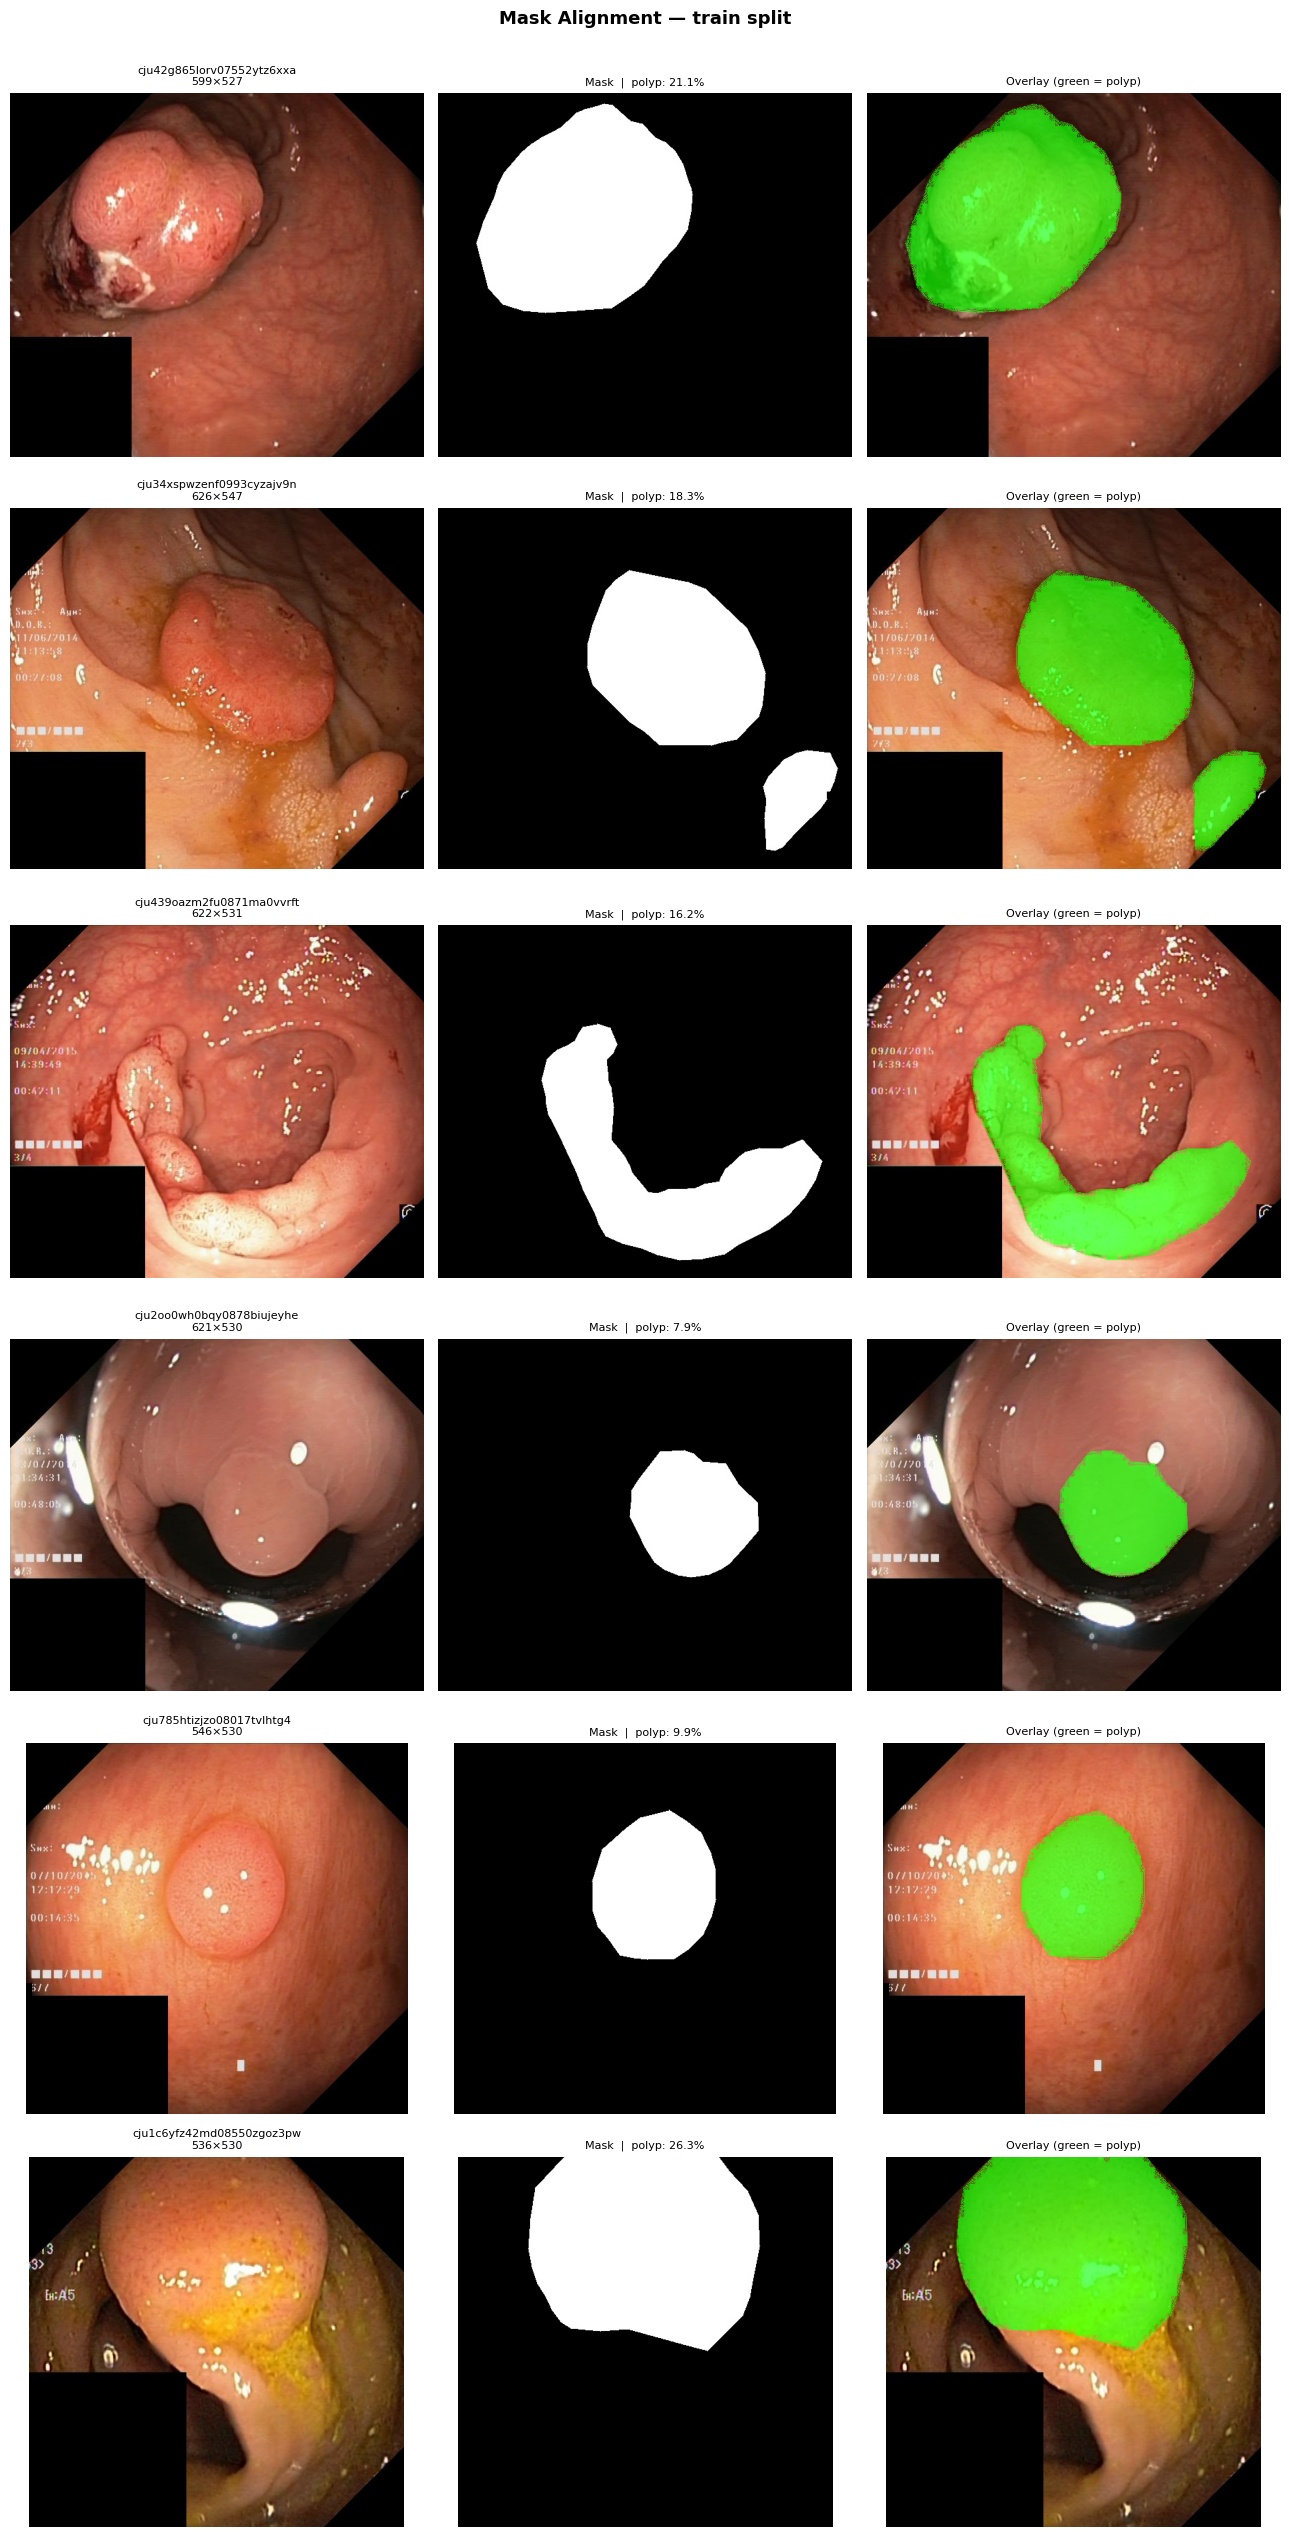

✅ Saved → Kvasir-SEG\overlay_check_train.png


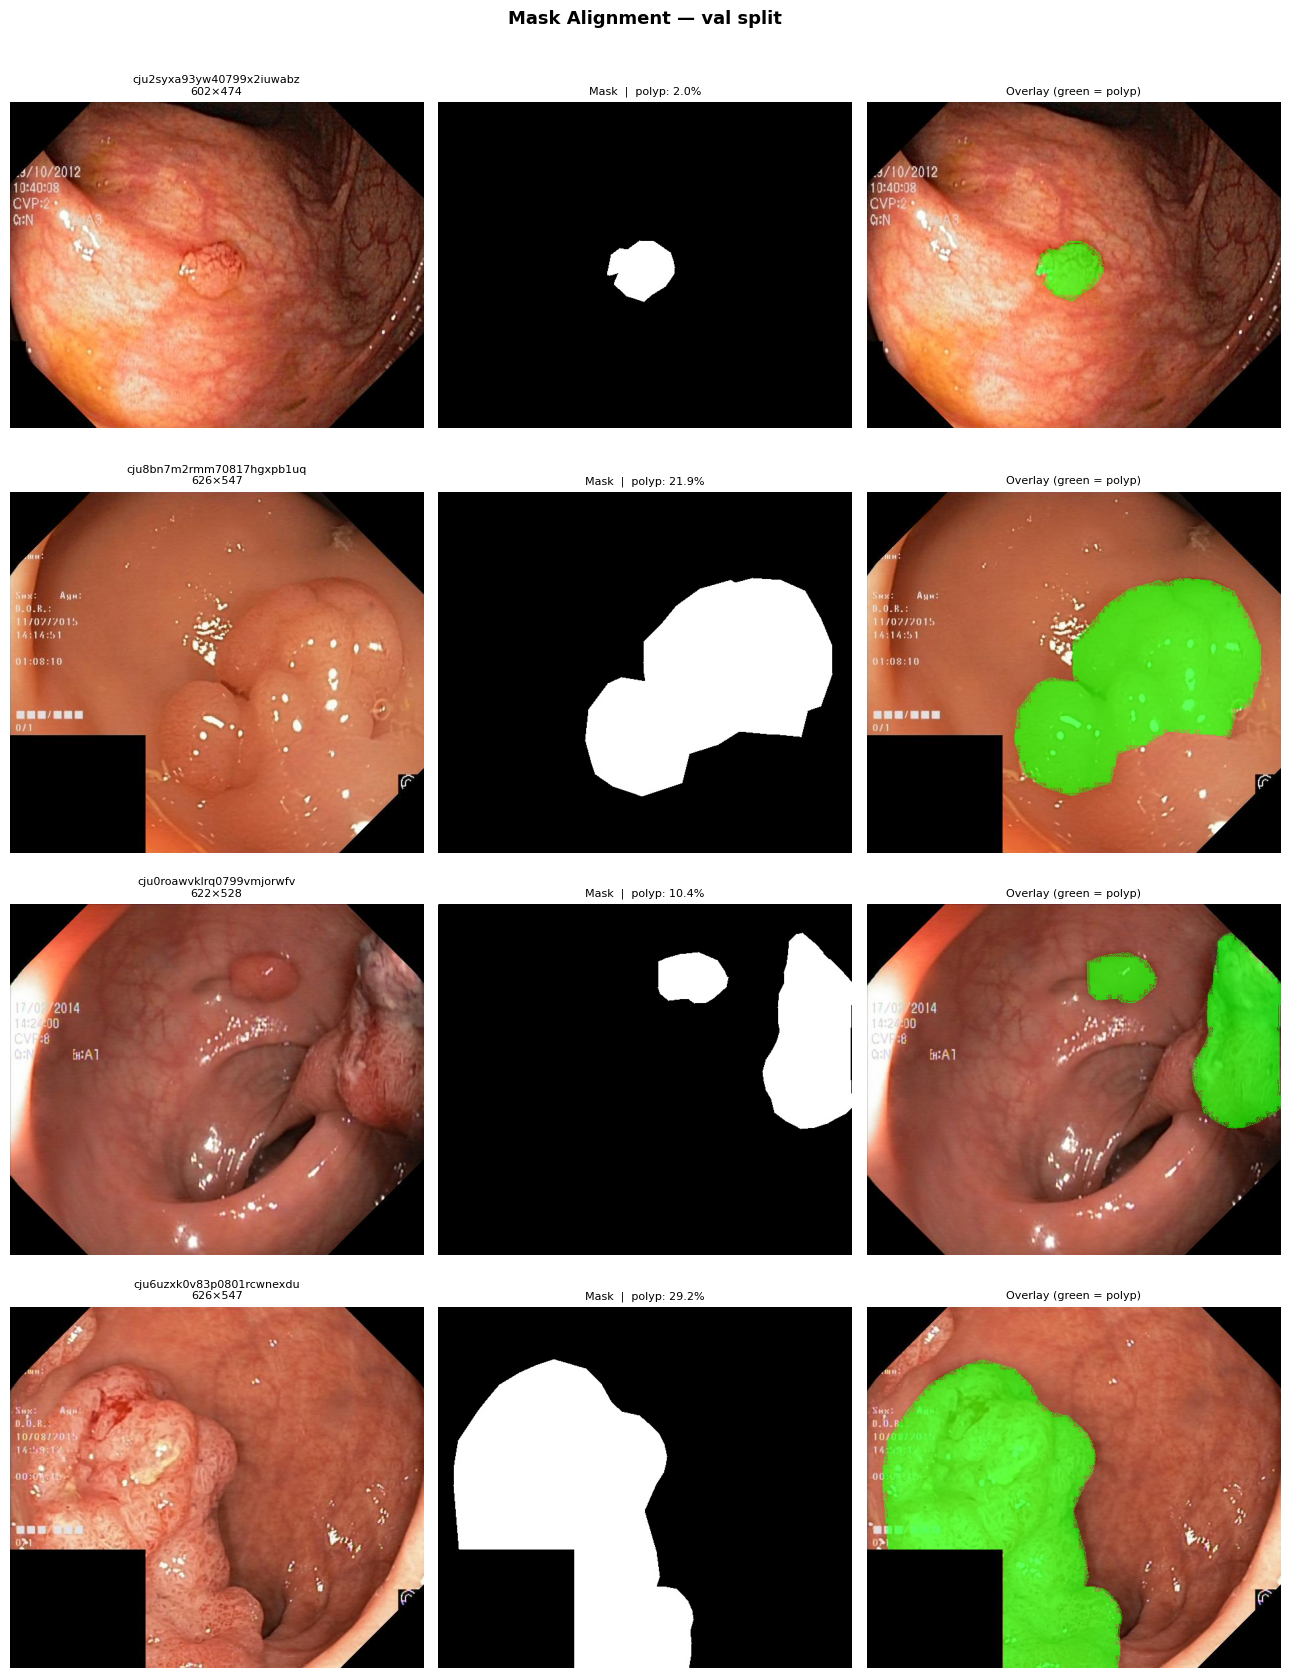

✅ Saved → Kvasir-SEG\overlay_check_val.png


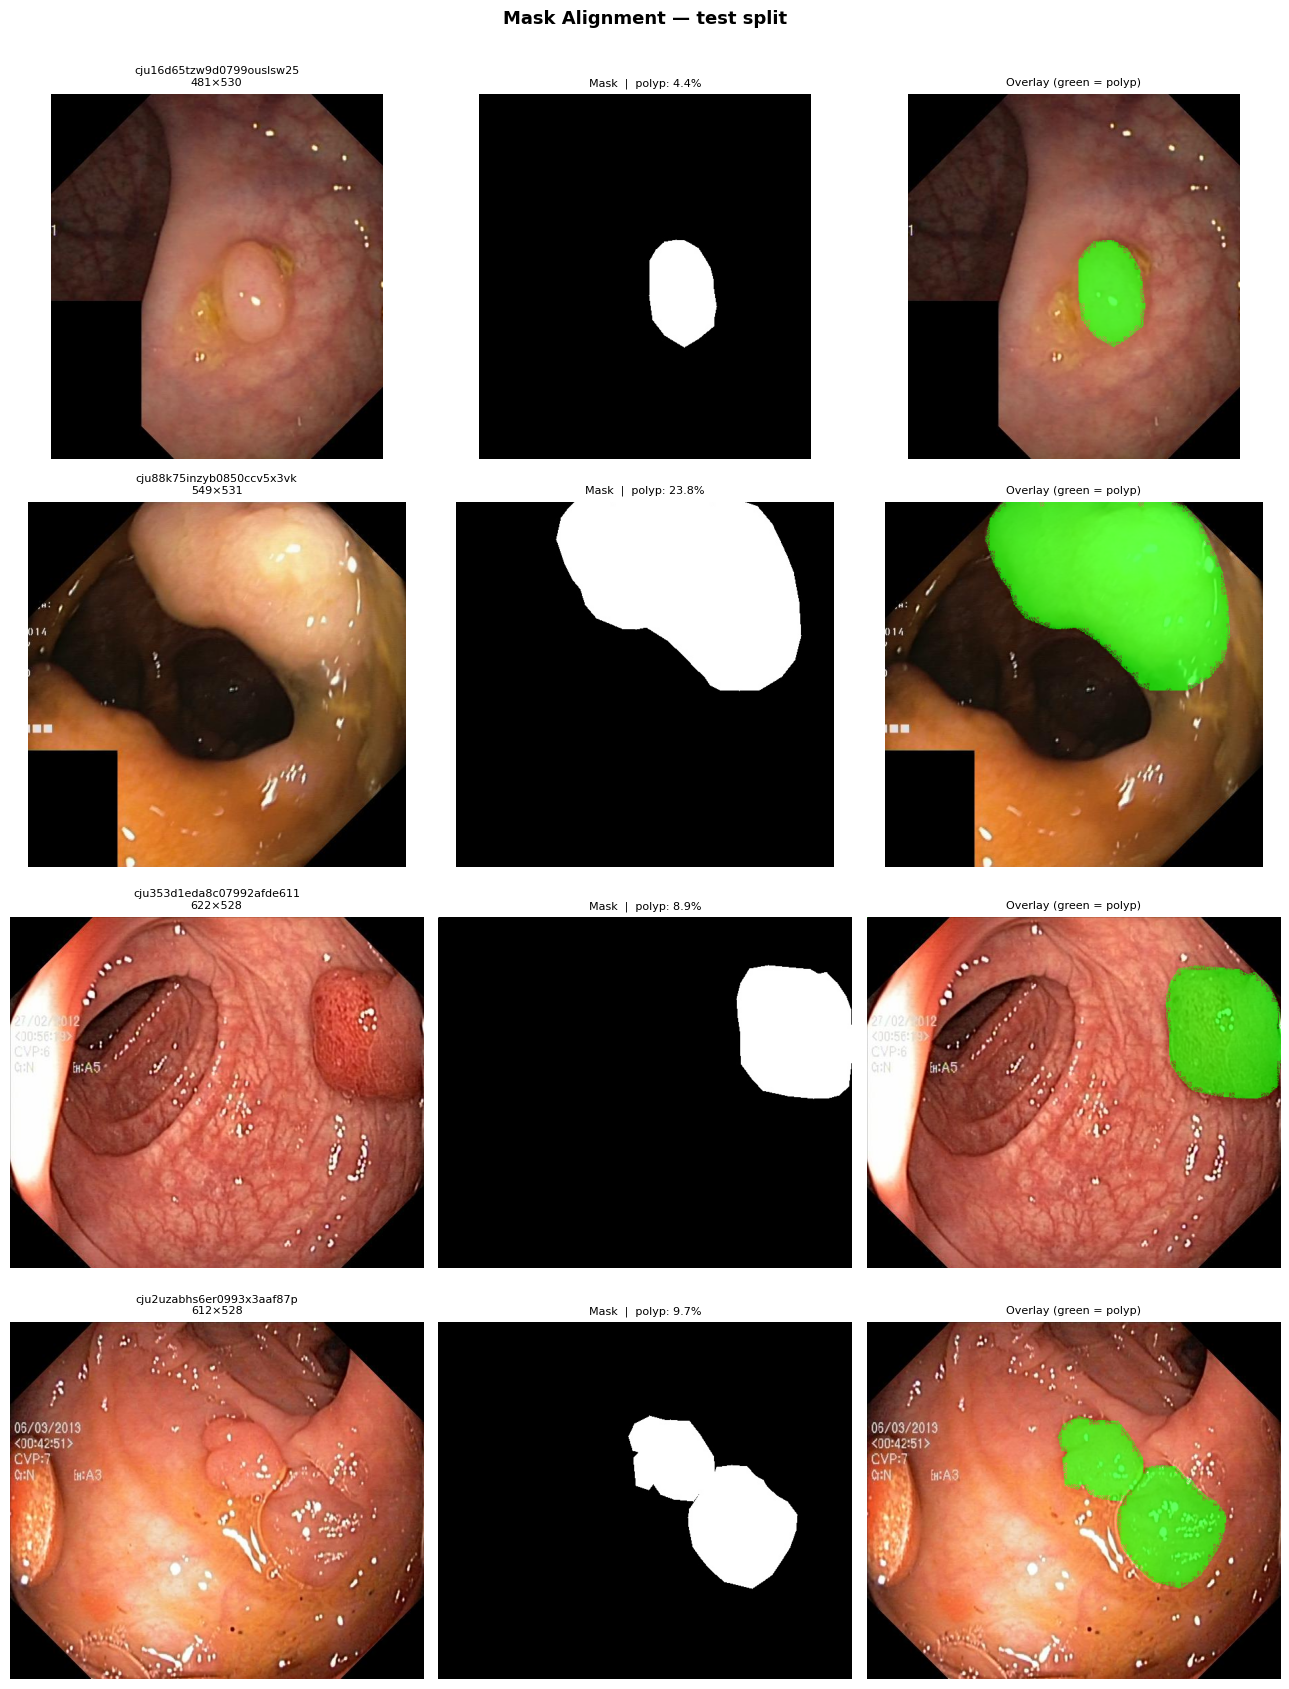

✅ Saved → Kvasir-SEG\overlay_check_test.png


In [71]:
def overlay_sanity_check(dataset, n_samples=6, seed=42):
    """
    Plots image | mask | green overlay for random samples.
    If green doesn't sit on the polyp → alignment is broken.
    """
    rng  = random.Random(seed)
    idxs = rng.sample(range(len(dataset)), min(n_samples, len(dataset)))

    fig, axes = plt.subplots(n_samples, 3, figsize=(13, 4.2 * n_samples))
    if n_samples == 1:
        axes = [axes]

    for row, idx in enumerate(idxs):
        image, mask = dataset.raw(idx)
        stem        = dataset.stems[idx]

        # Resize mask to image size if they differ (shouldn't happen after check above)
        if image.shape[:2] != mask.shape[:2]:
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]),
                              interpolation=cv2.INTER_NEAREST)

        # Build green overlay
        overlay = image.copy().astype(float)
        poly    = mask == 255
        overlay[poly, 0]  = overlay[poly, 0] * 0.4
        overlay[poly, 1]  = np.clip(overlay[poly, 1] * 0.4 + 180, 0, 255)
        overlay[poly, 2]  = overlay[poly, 2] * 0.4
        overlay = overlay.astype(np.uint8)

        h, w       = image.shape[:2]
        polyp_pct  = 100 * poly.mean()

        axes[row][0].imshow(image)
        axes[row][0].set_title(f"{stem}\n{w}×{h}", fontsize=8)
        axes[row][0].axis('off')

        axes[row][1].imshow(mask, cmap='gray')
        axes[row][1].set_title(f"Mask  |  polyp: {polyp_pct:.1f}%", fontsize=8)
        axes[row][1].axis('off')

        axes[row][2].imshow(overlay)
        axes[row][2].set_title("Overlay (green = polyp)", fontsize=8)
        axes[row][2].axis('off')

    plt.suptitle(f"Mask Alignment — {dataset.split} split", fontsize=13,
                 fontweight='bold', y=1.005)
    plt.tight_layout()
    out = SOURCE_ROOT / f"overlay_check_{dataset.split}.png"
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {out}")

overlay_sanity_check(train_ds, n_samples=6, seed=SEED)
overlay_sanity_check(val_ds,   n_samples=4, seed=SEED)
overlay_sanity_check(test_ds,  n_samples=4, seed=SEED)